# Imports

In [1]:
from pySVA.sva_core import *
from pySVA.sva_calc import *

In [2]:
from pySVA.sva_helpers import *

In [3]:
import dfm_tools as dfmt
import numpy as np
import xarray as xr

# Data description

In [4]:
data_description = {
    "nfaces": "mesh2d_nFaces",
    "depth": "mesh2d_nLayers",
    "time" : "time"
}

In [5]:
import numpy as np

# Set up dask cluster

In [6]:
from dask_jobqueue import SLURMCluster
from dask.distributed import Client

In [7]:
n_cores = 1
n_processes = 4
mem_lim = str(int(np.floor(336/(n_cores*n_processes))))+'GB' # 336 for genoa # 224 for rome

In [8]:
cluster = SLURMCluster(name='dask-cluster',
                       cores=n_cores,
                       memory=mem_lim,
                       processes=n_processes,
                       interface='ib0',
                       queue='genoa',
                       walltime='04:00:00',
                       asynchronous=0)

INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-6ldtlj17', purging
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-t72nnlx2', purging
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-m_63yted', purging
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-yttcvrdi', purging
INFO:distributed.diskutils:Found stale lock file and directory '/scratch-local/mgeraeds/dask-scratch-space/scheduler-ju2jpe91', purging
INFO:distributed.scheduler:  Scheduler at: tcp://172.22.63.192:35869
INFO:distributed.scheduler:  dashboard at:  http://172.22.63.192:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle


In [9]:
print(cluster.job_script())

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -p genoa
#SBATCH -n 1
#SBATCH --cpus-per-task=1
#SBATCH --mem=79G
#SBATCH -t 04:00:00

/home/mgeraeds/.conda/envs/dfm_proc_env/bin/python -m distributed.cli.dask_worker tcp://172.22.63.192:35869 --name dummy-name --nthreads 0 --memory-limit 19.56GiB --nworkers 4 --nanny --death-timeout 60 --interface ib0



In [10]:
cluster.scale(1)

In [11]:
client = Client(cluster)

INFO:distributed.scheduler:Receive client connection: Client-c5a95e26-f677-11ee-ad09-00001029fe80
INFO:distributed.core:Starting established connection to tcp://172.22.63.192:59452


In [12]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: http://172.22.63.192:8787/status,
Dashboard: http://172.22.63.192:8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.22.63.192:35869,Workers: 0
Dashboard: http://172.22.63.192:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [13]:
# file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/00_RMM3d_2022_simulations/computations/B02_2022_jul21-aug7/B02_2022_jul21-aug7_sm/RMM_dflowfm_2022_jul21_aug7_sm_000*_map.nc'

# Load dataset

In [13]:
file_nc = r'/projects/0/einf1300/saltis-wp3-1/C_Work/04_RMD_2022/computations/B04/B04_2022_jun23-24/ZUNO-zd_dflowfm_B04_jun23-24_0000_map.nc'

INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.98:37659', name: dask-cluster-0-2, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.58.98:37659
INFO:distributed.core:Starting established connection to tcp://172.22.58.98:54050
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.98:43115', name: dask-cluster-0-3, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.58.98:43115
INFO:distributed.core:Starting established connection to tcp://172.22.58.98:54056
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://172.22.58.98:43577', name: dask-cluster-0-0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://172.22.58.98:43577
INFO:distributed.core:Starting established connection to tcp://172.22.58.98:54034
INFO:distributed.scheduler:Register worker <WorkerState 't

In [37]:
data_xr = dfmt.open_partitioned_dataset(file_nc.replace('_0000_',"_*_"), chunks={'time':1})# "mesh2d_nFaces":50000, "mesh2d_nNodes":50000, "mesh2d_nEdges":50000})#, "mesh2d_nFaces":5000, "mesh2d_nNodes":5000, "mesh2d_nEdges":5000})

>> xu.open_dataset() with 96 partition(s): 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 : 81.48 sec
>> xu.merge_partitions() with 96 partition(s): 4.00 sec
>> some variables dropped with merging of partitions: ['mesh2d_face_x_bnd', 'mesh2d_face_y_bnd']
>> dfmt.open_partitioned_dataset() total: 85.53 sec


In [38]:
uds = data_xr

In [16]:
import xugrid as xu
import matplotlib.pyplot as plt

In [17]:
# > Get grid
grid = uds.grid

# > Get dimension and grid names
dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
dimn_faces = grid.face_dimension
dimn_edges = grid.edge_dimension
fill_value = grid.fill_value
gridname = grid.name
dimn_maxef = f'{gridname}_nMax_edge_faces'
dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
dimn_cart = f'{gridname}_nCartesian_coords'

In [18]:
sva_obj = constructorSVA(uds)

In [19]:
unvs = calculate_unit_normal_vectors(sva_obj)

In [20]:
# > Get the edge-face connectivity and replace fill values with -1
edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
edge_faces_validbool = edge_faces!=fill_value
edge_faces = edge_faces.where(edge_faces_validbool, -1)
    
# > Get the face-edge connectivity and replace fill values with -1
face_edges = build_face_edge_connectivity(sva_obj)
face_edges_validbool = face_edges!=fill_value
face_edges = face_edges.where(face_edges_validbool, -1)
face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

In [21]:
uda = uda_to_edges(sva_obj, uds['mesh2d_sa1'])

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [22]:
bool_drycells = (uds['mesh2d_s1'] - uds['mesh2d_flowelem_bl']) < 0.002 # 0.0001 # standard EPSHU #other option: 0.0025
uds_filt = uds.where(~bool_drycells)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 96
  result = blockwise(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 96
  result = blockwise(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 96
  result = blockwise(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 96
  result = blockwise(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/dask/array/core.py:4836: PerformanceWarning: Increasing number of chunks by factor of 96
  result = blockwise(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/dask/array/core.py:4836: PerformanceW

In [39]:
sva_obj = constructorSVA(uds)
sva_obj.ds.ugrid.set_crs("EPSG:28992")
sva_obj.ds = sva_obj.ds.ugrid.to_crs('WGS84')
sva_obj.tracer = sva_obj.ds['mesh2d_sa1']
sva_obj.velu1 = sva_obj.ds['mesh2d_u1']
sva_obj.flow_area = sva_obj.ds['mesh2d_au']
sva_obj.volume = sva_obj.ds['mesh2d_vol1']

In [40]:
sva_obj.tracer = uda_to_edges(sva_obj, sva_obj.tracer)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [45]:
sva_obj.ds

<xarray.Dataset>
Dimensions:                      (time: 45, mesh2d_nNodes: 133336,
                                  mesh2d_nFaces: 126438, mesh2d_nLayers: 46,
                                  mesh2d_nInterfaces: 47, Two: 2,
                                  mesh2d_nEdges: 259786,
                                  mesh2d_nCartesian_coords: 2)
Coordinates:
  * time                         (time) datetime64[ns] 2022-06-23 ... 2022-06-24
    mesh2d_node_x                (mesh2d_nNodes) float64 4.252 4.253 ... 4.459
    mesh2d_node_y                (mesh2d_nNodes) float64 51.79 51.79 ... 51.89
    mesh2d_face_x                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_face_y                (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_zcc          (time, mesh2d_nFaces, mesh2d_nLayers) float64 dask.array<chunksize=(1, 1315, 46), meta=np.ndarray>
    mesh2d_flowelem_zw           (time, mesh2d_nFaces, mesh2d_nInterfaces) float64 dask.array<chunksize=(1, 1315, 47), meta=np.ndarray>
    mesh2d_edge_x                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
    mesh2d_edge_y                (mesh2d_nEdges) float64 dask.array<chunksize=(2708,), meta=np.ndarray>
  * mesh2d_nEdges                (mesh2d_nEdges) int64 0 1 2 ... 259784 259785
  * mesh2d_nNodes                (mesh2d_nNodes) int64 0 1 2 ... 133334 133335
  * mesh2d_nFaces                (mesh2d_nFaces) int64 0 1 2 ... 126436 126437
Dimensions without coordinates: mesh2d_nLayers, mesh2d_nInterfaces, Two,
                                mesh2d_nCartesian_coords
Data variables: (12/46)
    projected_coordinate_system  int32 ...
    timestep                     (time) float64 dask.array<chunksize=(1,), meta=np.ndarray>
    mesh2d_node_z                (mesh2d_nNodes) float64 dask.array<chunksize=(1394,), meta=np.ndarray>
    mesh2d_bldepth               (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_ba           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_bl           (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    ...                           ...
    mesh2d_turkin1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float64 dask.array<chunksize=(1, 2708, 47), meta=np.ndarray>
    mesh2d_vicwwu                (time, mesh2d_nEdges, mesh2d_nInterfaces) float64 dask.array<chunksize=(1, 2708, 47), meta=np.ndarray>
    mesh2d_tureps1               (time, mesh2d_nEdges, mesh2d_nInterfaces) float64 dask.array<chunksize=(1, 2708, 47), meta=np.ndarray>
    mesh2d_cftrt                 (time, mesh2d_nEdges) float64 dask.array<chunksize=(1, 2708), meta=np.ndarray>
    mesh2d_unvs                  (mesh2d_nEdges, mesh2d_nCartesian_coords) float64 ...
    None_gradient                (time, mesh2d_nFaces, mesh2d_nLayers, mesh2d_nCartesian_coords) float64 dask.array<chunksize=(1, 1315, 46, 2), meta=np.ndarray>
Attributes:
    institution:               Deltares
    references:                https://www.deltares.nl
    source:                    D-Flow FM 1.2.184.12c3fe806c08f513ff343edfb8a6...
    history:                   Created on 2024-02-13T21:38:13+0100, D-Flow FM
    date_created:              2024-02-13T21:38:13+0100
    date_modified:             2024-02-13T21:38:13+0100
    Conventions:               CF-1.8 UGRID-1.0 Deltares-0.10 ACDD-1.3
    uuid:                      ca8716be-6119-44ea-8b9d-5236635c9faf
    time_coverage_start:       2022-06-23T02:30:00+00:00
    time_coverage_end:         2023-01-01T12:00:00+00:00
    time_coverage_duration:    P192DT9H30M0S
    time_coverage_resolution:  P0000-00-00T00:30:00

In [25]:
def compute_gradient_on_face(constructorSVA, uda, **kwargs):

    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
    dimn_cart = f'{gridname}_nCartesian_coords'

    # > Determine varname from the provided array\
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(constructorSVA)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges_validbool, unvs.isel({dimn_edges:face_edges}), np.nan)

    # // 2. See if the normal vectors are pointing out of the cell. If not, flip them.
    # > Calculate distance vectors
    dv = calculate_distance_vectors(constructorSVA)
    # > Calculate the dot product between the calculated normal vectors and the distance vector for each face
    i_nfs = xr.dot(fe_nfs, dv, dims=[dimn_cart])
    # > if the product < 1, multiply by -1 to get an outwards facing normal vector, and update the variable
    fe_nfs = xr.where(i_nfs > 0, fe_nfs, fe_nfs * -1)

	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)
        # > Replace locations of the validbools with NaN's
        edge_var = xr.where(face_edges_validbool, edge_var, np.nan)

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")

        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * edge_au * fe_nfs).sum(dim=dimn_maxfn, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        gradient = (1/volume) * face_vars
        uds[f'{gridname}_{varname}_gradient'] = gradient
        
        return gradient

    else: 
        raise ValueError('This function only supports the calculation of gradients at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')

	

In [42]:
gradient = compute_gradient_on_face(sva_obj, sva_obj.tracer)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [27]:
from dfmproc.utils.plotting import GeneralPlot, plot_basic_background

/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:36: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  cm.register_cmap(cmap = reg_map)
/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:40: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  cm.register_cmap(cmap = reg_map_r)
/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:36: MatplotlibDeprecationWarning: The register_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps.register(name)`` instead.
  cm.register_cmap(cmap = reg_map)
/gpfs/home2/mgeraeds/Repositories/cmestuary/cmestuary/cm.py:40: MatplotlibDeprecationWarning: The register_cmap function was deprecate

In [28]:
import cmocean.cm as cmo

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

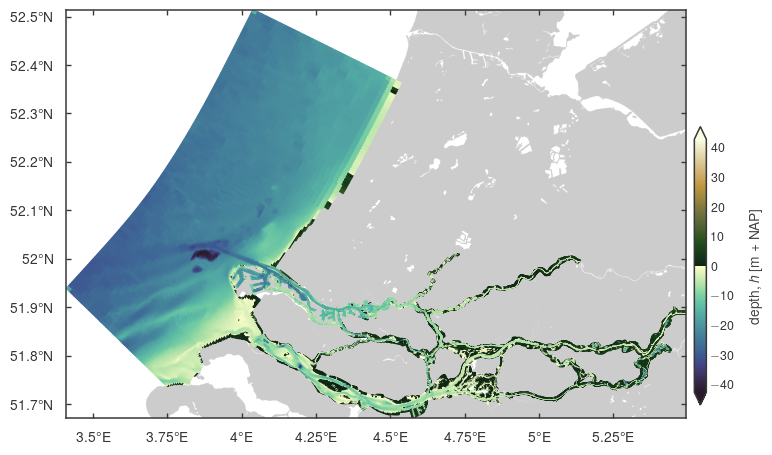

In [193]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(8,6.5))#6,5
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=0)

pc = sva_obj.ds['mesh2d_flowelem_bl'].ugrid.plot(cmap=cmo.topo, add_labels=False, add_colorbar=False, zorder=1)
# g = uds.ugrid.grid.plot(add_labels=False, add_colorbar=False, zorder=2, lw=.5)#, color='red')

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r'depth, $h$ [m + NAP]'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 
plt.savefig('bathymetry_RMD.png', transparent=True)

In [29]:
dimn_cart = f'mesh2d_nCartesian_coords'

In [43]:
salinity_gradient = np.sqrt(gradient.isel({dimn_cart:0})**2 + gradient.isel({dimn_cart:1})**2)#.where(~bool_drycells)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use public APIs instead.
  srs = pd.Series(*args, **kwargs)
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/pandas/core/frame.py:706: DeprecationWarning: Passing a BlockManager to GeoDataFrame is deprecated and will raise in a future version. Use public APIs instead.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/geopandas/geodataframe.py:1640: DeprecationWarning: Passing a SingleBlockManager to Series is deprecated and will raise in a future version. Use publ

Text(0.5, 1.0, '2022/06/23 02:30, LW')

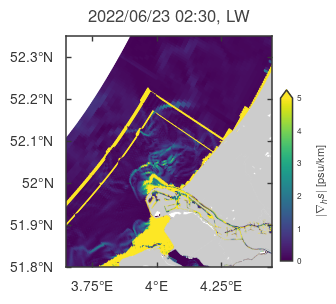

In [44]:
t = '2022/06/23 02:30'
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(4,3))
bg = plot_basic_background(ax=ax, crs='WGS84', zorder=1)
pc = (salinity_gradient*1000).where(~bool_drycells).isel(mesh2d_nLayers=45).sel(time=t).ugrid.sel(y=slice(51.8, 52.4), x=slice(3.6, 4.5)).ugrid.plot(ax=ax,add_labels=False, add_colorbar=False, vmax=5, zorder=0)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.03, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
ax.set_ylim(51.8, 52.35)
ax.set_xlim(3.65, 4.45)
cb = plt.colorbar(pc, cax=cax, extend='max')
tracer_string = r'$|\nabla_h s|$ [psu/km]'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=8)
cb.ax.tick_params(labelsize=6) 
ax.set_title(f'{t}, LW')
# plt.savefig('fronts_LW.png', transparent=True)

In [37]:
div = compute_divergence_on_face(sva_obj, sva_obj.velu1)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 13.69 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163

In [36]:
f = 2 * 7.2921E-5 * np.sin(51.92651)

In [120]:
fig, ax = plt.subplots(FigureClass=GeneralPlot, figsize=(6,5))
bg = plot_basic_background(ax=ax, crs='EPSG:28992', zorder=0)

pc=(div).isel(time=20, mesh2d_nLayers=45).ugrid.sel(x=slice(45_000, 85_000), y=slice(450_000, 480_000)).ugrid.plot(extend='both', cmap=cmo.balance, zorder=1, add_labels=False, add_colorbar=False)

# add colorbar
cax = fig.add_axes([ax.get_position().x1 + 0.01, ax.get_position().y0 + 0.02, 0.015, ax.get_position().height - 0.2])
cax.tick_params(axis=u'both', which=u'both', length=0)

# cbar limits + others
cb = plt.colorbar(pc, cax=cax, extend='both')
tracer_string = r'$\nabla\cdot\mathbf{u}$'
cb.set_label(f'{tracer_string}', labelpad=10, fontsize=10)
cb.ax.tick_params(labelsize=9) 

In [143]:
uds['mesh2d_ucx'].shape

(45, 126438, 46)

In [154]:
ucx_edge = uda_to_edges(sva_obj, sva_obj.ds.mesh2d_ucx)
ucy_edge = uda_to_edges(sva_obj, sva_obj.ds.mesh2d_ucy)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [155]:
ucx_grad = compute_gradient_on_face(sva_obj, ucx_edge)
ucy_grad = compute_gradient_on_face(sva_obj, ucy_edge)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat

In [157]:
div = ucx_grad.isel({f'{dimn_cart}':0}) + ucy_grad.isel({f'{dimn_cart}':1})

In [167]:
def compute_divergence_on_face(constructorSVA, uda, **kwargs):
    # For this function, the vector on the edge needs to be in the direction of the normal vector!!
    from dfm_tools.xugrid_helpers import get_vertical_dimensions
    
    # > Obtain uds from constructorSVA object
    uds = constructorSVA.ds

    # > Get grid
    grid = uds.grid

    # > Get dimension and grid names
    dimn_maxfn = grid.to_dataset().mesh2d.attrs['max_face_nodes_dimension']
    dimn_faces = grid.face_dimension
    dimn_edges = grid.edge_dimension
    fill_value = grid.fill_value
    gridname = grid.name
    dimn_maxef = f'{gridname}_nMax_edge_faces'
    dimn_layer, dimn_interfaces = get_vertical_dimensions(uds)
    dimn_cart = f'{gridname}_nCartesian_coords'

    # > Determine varname from the provided array
    varname = uda.name

    # > Calculate the unit normal vectors if not in the dataset already
    try:
        unvs = kwargs['unvs']
    except:
        unvs = calculate_unit_normal_vectors(constructorSVA)
    
    # > Get the volume and flow area variables: check if they're in the 
    # > constructor first, then check the dataset, else throw error
    try:
        flow_area = constructorSVA.flow_area
    except:
        try:
            flow_area = uds[f'{gridname}_au'] # todo: extend to more arbitrary names in later stage
        except: 
            raise NameError('Could not retrieve the flow area, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')
    
    try:
        volume = constructorSVA.volume
    except:
        try:
            volume = uds[f'{gridname}_vol1']# todo: extend to more arbitrary names in later stage
        except:
            raise NameError('Could not retrieve the volume of the cells, which is necessary for the gradient \
                             calculation. Please provide volume variable in the constructor or in the underlying dataset.')

    # > Get the edge-face connectivity and replace fill values with -1
    edge_faces = xr.DataArray(uds.ugrid.grid.edge_face_connectivity, dims=(dimn_edges, dimn_maxef))
    edge_faces_validbool = edge_faces!=fill_value
    edge_faces = edge_faces.where(edge_faces_validbool, -1)
        
    # > Get the face-edge connectivity and replace fill values with -1
    face_edges = build_face_edge_connectivity(constructorSVA)
    face_edges_validbool = face_edges!=fill_value
    face_edges = face_edges.where(face_edges_validbool, -1)
    face_edges_stacked = face_edges.stack(__tmp_dim__=(dimn_faces, dimn_maxfn))

    # > Get the unit normal vectors (nf) also in the face-edges matrix
    fe_nfs = xr.where(face_edges_validbool, unvs.isel({dimn_edges:face_edges}), np.nan)

	# > Determine if we're looking at a velocity value u1 or u0
    # > Because these are vector quantities in the direction of the normal vector,
    # > to get to the final vector, we have to multiply u1/u0 by the normal vector
    # > first. Also, we need to check their sign for every edge.
    if dimn_edges in uda.dims:
        # > Make sure the edge dimension is not chunked, otherwise we will 
        # > get "PerformanceWarning: Slicing with an out-of-order index is generating x times more chunks."
        chunks = {dimn_edges:-1}
        uda = uda.chunk(chunks)

        # > Fill the face-edges matrix with the varname
        # > Do this via stack and unstack since 2D indexing does not
        # > properly work in dask yet: https://github.com/dask/dask/pull/10237
        edge_var_stacked = uda.isel({dimn_edges: face_edges_stacked})
        edge_var = edge_var_stacked.unstack("__tmp_dim__")
        # > Convert data-array back to an xu.UgridDataArray
        edge_var = xu.UgridDataArray(edge_var, grid=grid)
        edge_var = xr.where(face_edges_validbool, edge_var, np.nan)

        # > Fill face_edge matrix with flow area data
        flow_area = flow_area.chunk(chunks)
        edge_au_stacked = flow_area.isel({dimn_edges:face_edges_stacked})
        edge_au = edge_au_stacked.unstack("__tmp_dim__")
        edge_au = xr.where(face_edges_validbool, edge_au, np.nan)
        
        # > Multiply the variable with the edge area (flow area), multiply by the 
        # > "flipped boolean" and the unit normal vector, and sum (dimension: faces)
        face_vars = (edge_var * fe_nfs * edge_au).sum(dim=dimn_maxfn, keep_attrs=True).sum(dim=dimn_cart, keep_attrs=True)
        
        # > Multiply the total result with (1/cell volume) (dimension: faces)
        uds[f'{varname}_divergence'] = divergence = (1/volume) * face_vars
        
        return divergence

    else: 
        raise ValueError('This function only supports the calculation of the divergence at face location, \
                         based on data on edges. Please supply a variable that is located on the edges.')


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 47.08 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


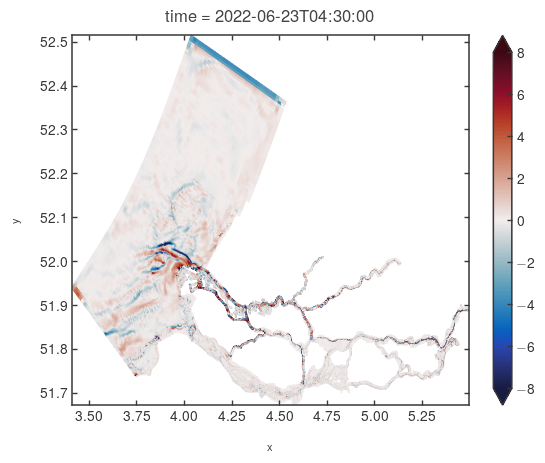

In [178]:
((ucx_grad.isel(mesh2d_nCartesian_coords=0)+ucy_grad.isel(mesh2d_nCartesian_coords=1))/f).isel(mesh2d_nLayers=45, time=5).ugrid.plot(vmin=-8,vmax=8,cmap=cmo.balance)

/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/distributed/client.py:3163: UserWarning: Sending large graph of size 37.21 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(


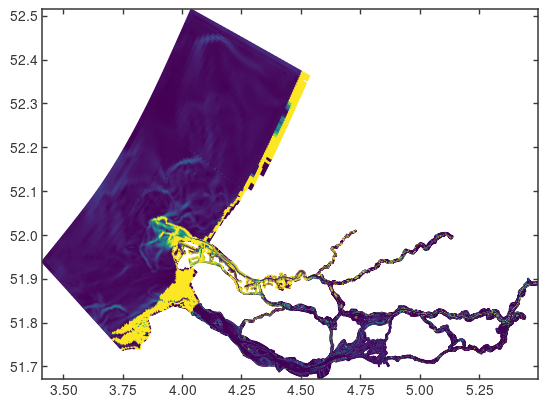

In [188]:
(salinity_gradient*1000).isel(mesh2d_nLayers=45, time=5).ugrid.plot(add_labels=False, add_colorbar=False, vmax=5, zorder=0)

In [187]:
salinity_gradient

<xarray.DataArray (time: 45, mesh2d_nFaces: 126438, mesh2d_nLayers: 46)>
dask.array<sqrt, shape=(45, 126438, 46), dtype=float64, chunksize=(1, 1318, 46), chunktype=numpy.ndarray>
Coordinates:
  * time                 (time) datetime64[ns] 2022-06-23 ... 2022-06-24
    mesh2d_face_x        (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_face_y        (mesh2d_nFaces) float64 dask.array<chunksize=(1315,), meta=np.ndarray>
    mesh2d_flowelem_zcc  (time, mesh2d_nFaces, mesh2d_nLayers) float64 dask.array<chunksize=(1, 1315, 46), meta=np.ndarray>
  * mesh2d_nFaces        (mesh2d_nFaces) int64 0 1 2 3 ... 126435 126436 126437
Dimensions without coordinates: mesh2d_nLayers

In [168]:
div = compute_divergence_on_face(sva_obj, sva_obj.velu1)

Unit normal vectors on edges already present Dataset in variable mesh2d_unvs.


/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array.reshape(shape)Explictly passing ``limit`` to ``reshape`` will also silence this warning
    >>> array.reshape(shape, limit='128 MiB')
  result = result._unstack_full_reindex(
/home/mgeraeds/.conda/envs/dfm_proc_env/lib/python3.9/site-packages/xarray/core/dataset.py:5557: PerformanceWarning: Reshaping is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array.reshape(shape)

To avoid creat